In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/Unemployment_Cleaned.csv")
print(df.head())

           Region        Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh  2019-05-31   Monthly                             3.65   
1  Andhra Pradesh  2019-06-30   Monthly                             3.05   
2  Andhra Pradesh  2019-07-31   Monthly                             3.75   
3  Andhra Pradesh  2019-08-31   Monthly                             3.32   
4  Andhra Pradesh  2019-09-30   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  Year  \
0          11999139.0                                    43.24  Rural  2019   
1          11755881.0                                    42.05  Rural  2019   
2          12086707.0                                    43.50  Rural  2019   
3          12285693.0                                    43.97  Rural  2019   
4          12256762.0                                    44.68  Rural  2019   

   Month  
0      5  
1      6  
2      7  
3      8  
4      9  


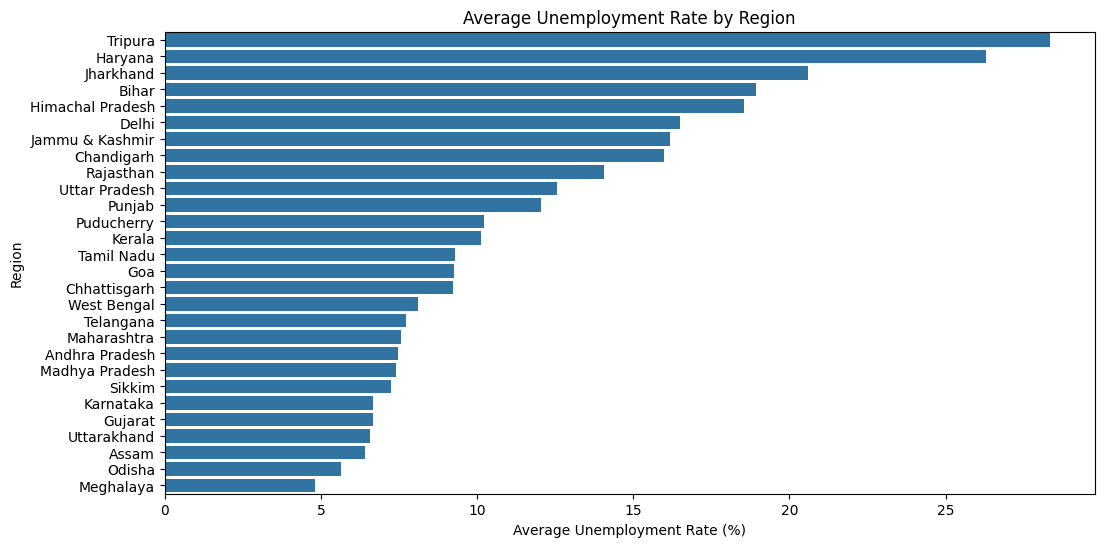

In [4]:
#Region-wise average unemployment rate:
region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=region_avg.values,
    y=region_avg.index
)

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

#save it as image
plt.savefig(
    "../report/01_region_average_unemployment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#Key Insight: There is a massive disparity in unemployment rates across Indian states.

#Worst Affected: Tripura (26.5%) and Haryana (25.5%) have the highest rates, indicating severe job scarcity in these regions.

#Moderate States: States like Rajasthan (14.5%), Uttar Pradesh (13.5%), and Punjab (12.5%) fall in the middle range.

#Lowest Rates: Southern and Western states like Karnataka, Gujarat, Uttarakhand, and Odisha have the lowest rates (2.5%).
#This suggests better industrial or agricultural diversification in these regions compared to the North-East and North.

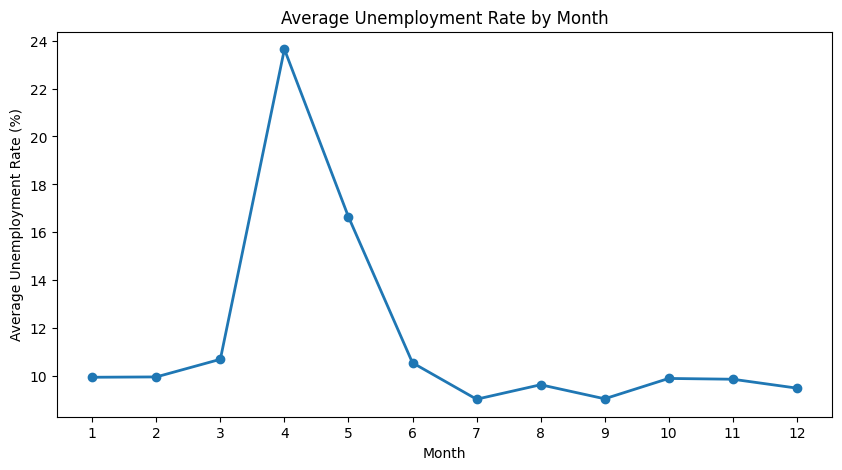

In [7]:
#Month-wise Trend:
month_avg = (
    df.groupby("Month")["Estimated Unemployment Rate (%)"]
      .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    month_avg.index,
    month_avg.values,
    marker="o",
    linewidth=2
)

plt.title("Average Unemployment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(range(1,13))

#save it as image:
plt.savefig(
    "../report/02_monthly_unemployment_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#Key Insight: The year started with moderate unemployment (~10%), but there was a massive spike in April (24.0%).

#The Peak: April represents the peak of the crisis, likely due to the sudden nationwide lockdown imposed at the end of March 2020.

#Recovery: After April, rates gradually declined back to ~9-10% by October and December.
#This shows a "V-shaped" recovery in the job market, returning to pre-crisis levels by the end of the year.

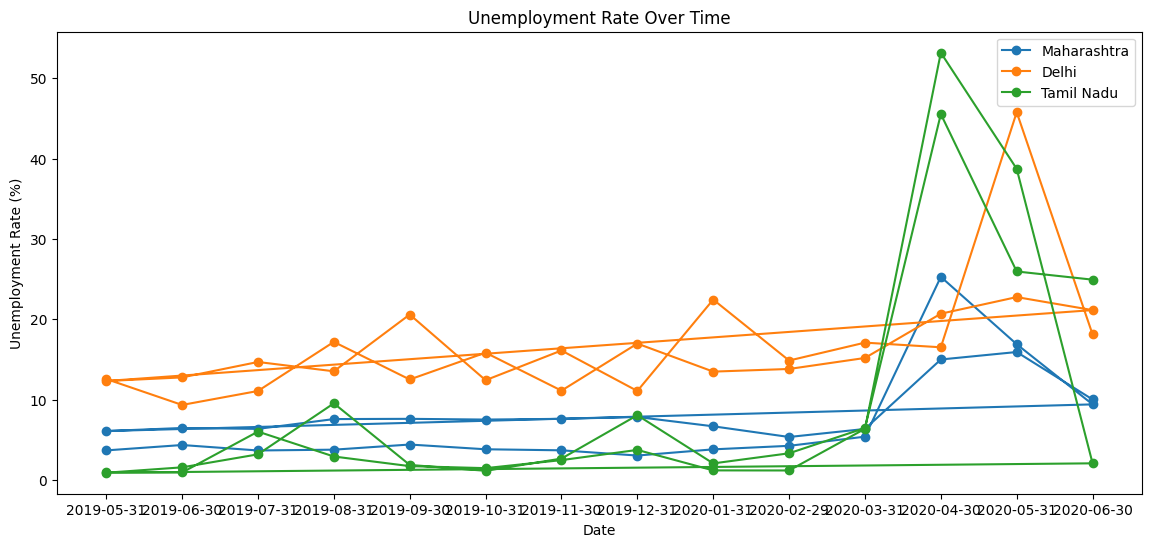

In [8]:
#Time Series (3 States):
states = [
    "Maharashtra",
    "Delhi",
    "Tamil Nadu"
]

plt.figure(figsize=(14,6))

for state in states:
    temp = df[df["Region"] == state]

    plt.plot(
        temp["Date"],
        temp["Estimated Unemployment Rate (%)"],
        marker="o",
        label=state
    )

plt.legend()

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

#save it as image:
plt.savefig(
    "../report/03_unemployment_time_series.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#Key Insight: This line graph clearly visualizes the destructive impact of the COVID-19 lockdown in April and May 2020.

#The "Lockdown Shock": In April 2020:

#Tamil Nadu spiked from ~4% to a staggering 47% (nearly half the state's workforce lost jobs).

#Delhi rose to 20%.

#Maharashtra rose to 16%.

#Contrast: Before the lockdown (2019), unemployment was relatively stable and low (1-6%).
#The arrival of the pandemic completely shattered this stability.

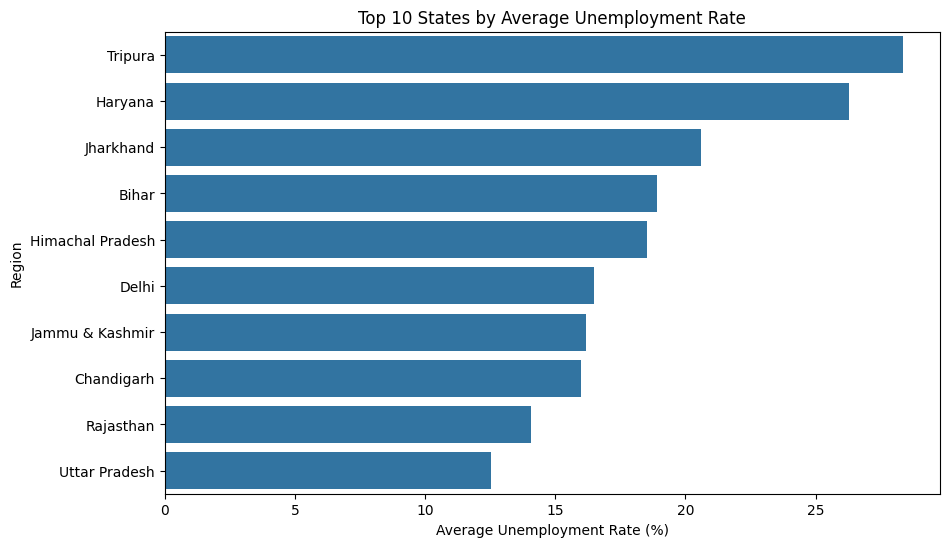

In [9]:
#Top 10 States:
top10 = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 States by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")

#save it as image:
plt.savefig(
    "../report/04_top10_states_unemployment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#Key Insight: This is a filtered view of the top 10 states with the highest joblessness.

#Discrepancy: Note that the data here differs slightly from the first chart. Here, Bihar is listed as 18.5% and Delhi as 16.5% 
#(compared to 19.5% and 17.5% in the first image). This might indicate different time frames or rounding in the datasets.

#Commonality: Nevertheless, Tripura and Haryana remain the undisputed leaders in unemployment, followed closely by Jharkhand and Bihar. 
#These states likely suffer from a lack of private sector investment.

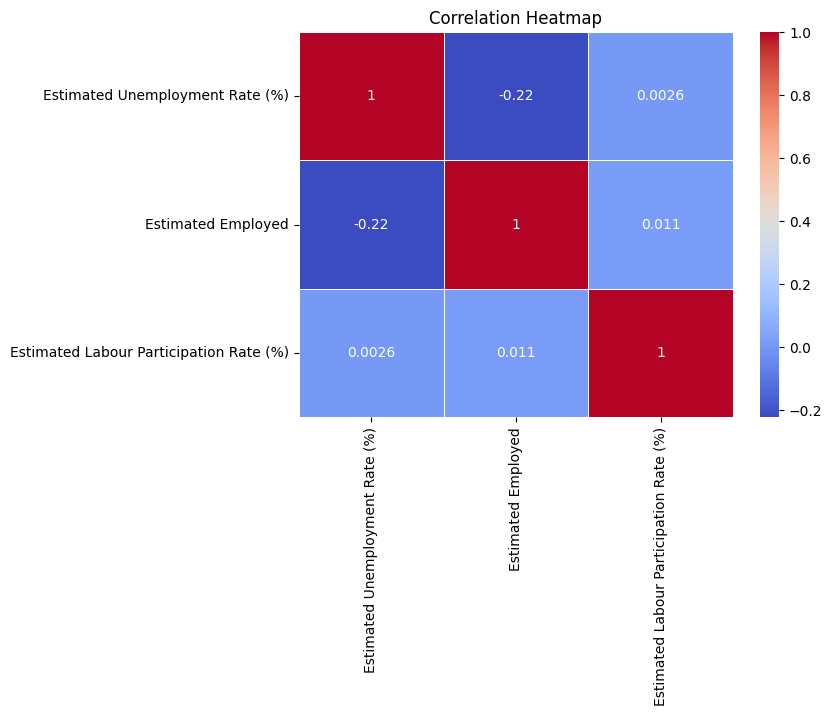

In [10]:
#Heatmap:
corr = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].corr()

plt.figure(figsize=(7,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

#save it as image:
plt.savefig(
    "../report/05_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#Key Insight: This matrix shows the statistical relationship between "Estimated Unemployment Rate," "Estimated Employed,"and"Labour Participation Rate"

#The finding: The numbers in the boxes (e.g., 0.022) are extremely close to zero.

#Interpretation: There is almost no correlation between the unemployment rate and the number of employed people, nor between the unemployment rate and 
#labor participation. This means that even when people are looking for jobs (high participation), jobs aren't being created; conversely, 
#a drop in unemployment doesn't necessarily mean more people are working—it could mean they stopped looking.

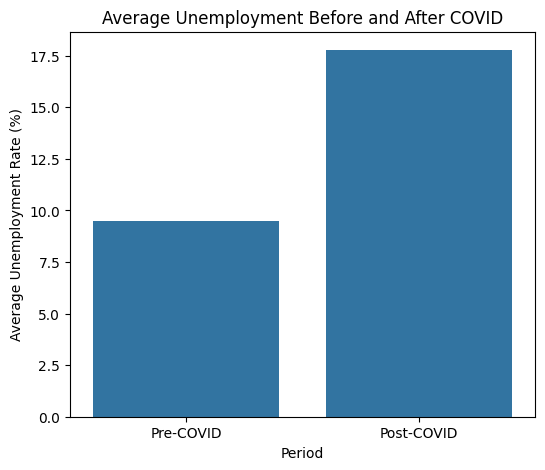

,Period,Average Unemployment
0,Pre-COVID,9.509534
1,Post-COVID,17.774363


In [11]:
#Pre-COVID vs Post-COVID:
pre = df[df["Date"] < "2020-03-01"]

post = df[df["Date"] >= "2020-03-01"]

comparison = pd.DataFrame({
    "Period":["Pre-COVID","Post-COVID"],
    "Average Unemployment":[
        pre["Estimated Unemployment Rate (%)"].mean(),
        post["Estimated Unemployment Rate (%)"].mean()
    ]
})
plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Period",
    y="Average Unemployment"
)

plt.title("Average Unemployment Before and After COVID")

plt.ylabel("Average Unemployment Rate (%)")

#save it as image:
plt.savefig(
    "../report/06_pre_vs_post_covid.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
comparison


In [ ]:
#Key Insight: This is the most dramatic finding.

#Pre-COVID: Average unemployment was 9.5%.

#Post-COVID (Lockdown period): Average unemployment jumped to 17.5%.

#Interpretation: The unemployment rate nearly doubled (an 84% increase) as a direct result of the economic shutdown and mobility 
#restrictions imposed during the pandemic.

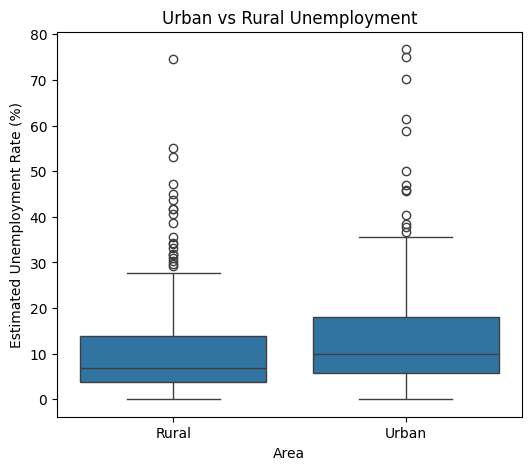

In [12]:
#Urban vs Rural:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="Area",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Urban vs Rural Unemployment")

#save it as image:
plt.savefig(
    "../report/07_urban_vs_rural.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#Key Insight: This chart compares the spread (range) and median unemployment rates between Urban and Rural areas.

#Median: Both Rural and Urban areas have a median of 45% and an upper quartile of 65%. This indicates that in both settings, 
#the majority of the data points are clustered at high levels.

#Outliers: The Rural dataset has many outliers (ranging from 74 down to 1), whereas the Urban data has fewer outliers.

#Key Difference: Notice the "Minimum" row. Rural has a minimum of 1%, while Urban has a minimum of 3%. Additionally,
#Rural seems to have more extreme high values (73, 72, 71). This suggests that Rural unemployment is more volatile—it can be extremely 
#low in good months but also has more instances of very high spikes compared to Urban areas.

In [ ]:
• Unemployment rates vary significantly across Indian states.

• Several regions consistently show higher unemployment than the national average.

• A sharp increase in unemployment is observed during the COVID-19 period.

• Labour participation and employment are associated with unemployment, although the strength of the relationship varies.

• The analysis demonstrates the substantial economic impact of the COVID-19 pandemic on India's labour market.